# GSE122149

## Imports

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../src")))

from load_data import load_counts, load_series_matrix
from metadata import build_metadata
from scoring import log2_transform
from plotting import set_plot_style, plot_pca, plot_clustermap, plot_gene_clustermap

set_plot_style()

## Load Normalized Counts

In [2]:
counts = load_counts("../data/raw/GSE122149_Smanes_normalized_counts.txt.gz")
print(counts.shape)
counts.head()

(15038, 21)


,39E76hSINACT,46E86hSINACT,53E96hSINACT,33E76hACT,40E86hACT,47E96hACT,34E724hACT,41E824hACT,48E924hACT,35E748hACT,...,49E948hACT,36E76hPDL1,43E86hPDL1,50E96hPDL1,37E724hPDL1,44E824hPDL1,51E924hPDL1,38E748hPDL1,45E848hPDL1,52E948hPDL1
gene,,,,,,,,,,,,,,,,,,,,,
7SK,3.562591,4.284355,5.237833,2.890315,3.707555,3.623706,0.816940,0.871556,2.539618,1.722823,...,1.844777,1.776241,4.284376,6.027480,2.390034,2.440874,4.070535,1.617917,4.085358,3.261046
A1BG,7.125182,5.141226,3.491888,4.817191,4.634443,3.623706,4.901638,6.100890,5.925775,6.029879,...,2.767165,5.328723,4.284376,4.305343,5.576746,4.881748,3.256428,5.662709,4.902430,4.891569
A1BG-AS1,13.359716,13.709936,12.221609,11.561259,1.853777,1.811853,12.254094,13.073336,1.693078,12.921169,...,8.301496,15.098048,12.853129,12.054960,2.390034,13.831620,13.839820,17.797085,13.073145,15.489969
A2M-AS1,4.453239,5.141226,6.983777,3.853753,4.634443,6.341485,3.267758,1.743111,3.386157,1.722823,...,1.844777,3.552482,5.141252,6.888548,7.170102,1.627249,11.397499,8.898542,10.621931,12.228923
AAAS,13.359716,18.851162,1.745944,14.451574,15.757107,15.400749,23.691248,28.761340,28.782334,4.307056,...,40.585094,15.098048,22.278757,16.360302,17.526915,21.967867,22.794997,19.415001,22.878005,20.381538


## Load sample metadata

In [3]:
meta = build_metadata(load_series_matrix("../data/raw/GSE122149_series_matrix.txt.gz"))
print(meta.shape)
meta.head()

(21, 4)


,geo_accession,title,timepoint,condition
sample_id,,,,
33E76hACT,GSM3456159,"33E76hACT: E7 Activated CD8+ T cells, time poi...",6h,activated_CD3_CD28
34E724hACT,GSM3456160,"34E724hACT: E7 Activated CD8+ T cells, time po...",24h,activated_CD3_CD28
35E748hACT,GSM3456161,"35E748hACT: E7 Activated CD8+ T cells, time po...",48h,activated_CD3_CD28
36E76hPDL1,GSM3456162,"36E76hPDL1: E7 Activated+PDL1 CD8+ T cells, ti...",6h,activated_PD1_PDL1
37E724hPDL1,GSM3456163,"37E724hPDL1: E7 Activated+PDL1 CD8+ T cells, t...",24h,activated_PD1_PDL1


## Apply log2(x+1) transform to normalized counts

In [4]:
expr = log2_transform(counts)

## PCA

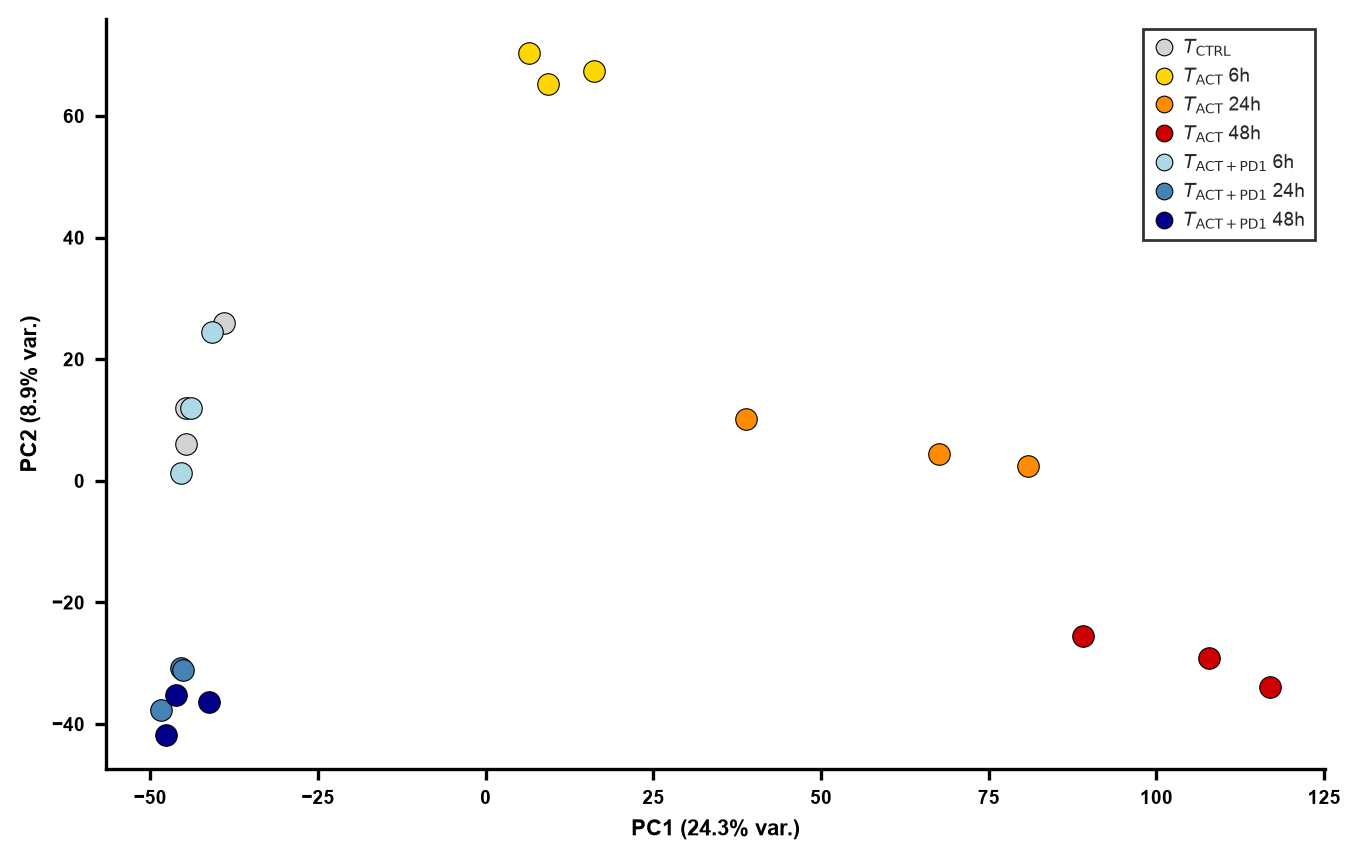

In [5]:
plot_pca(expr, meta, out_path="../outputs/figures/pca_by_condition_timepoint.png")

## Clustermaps

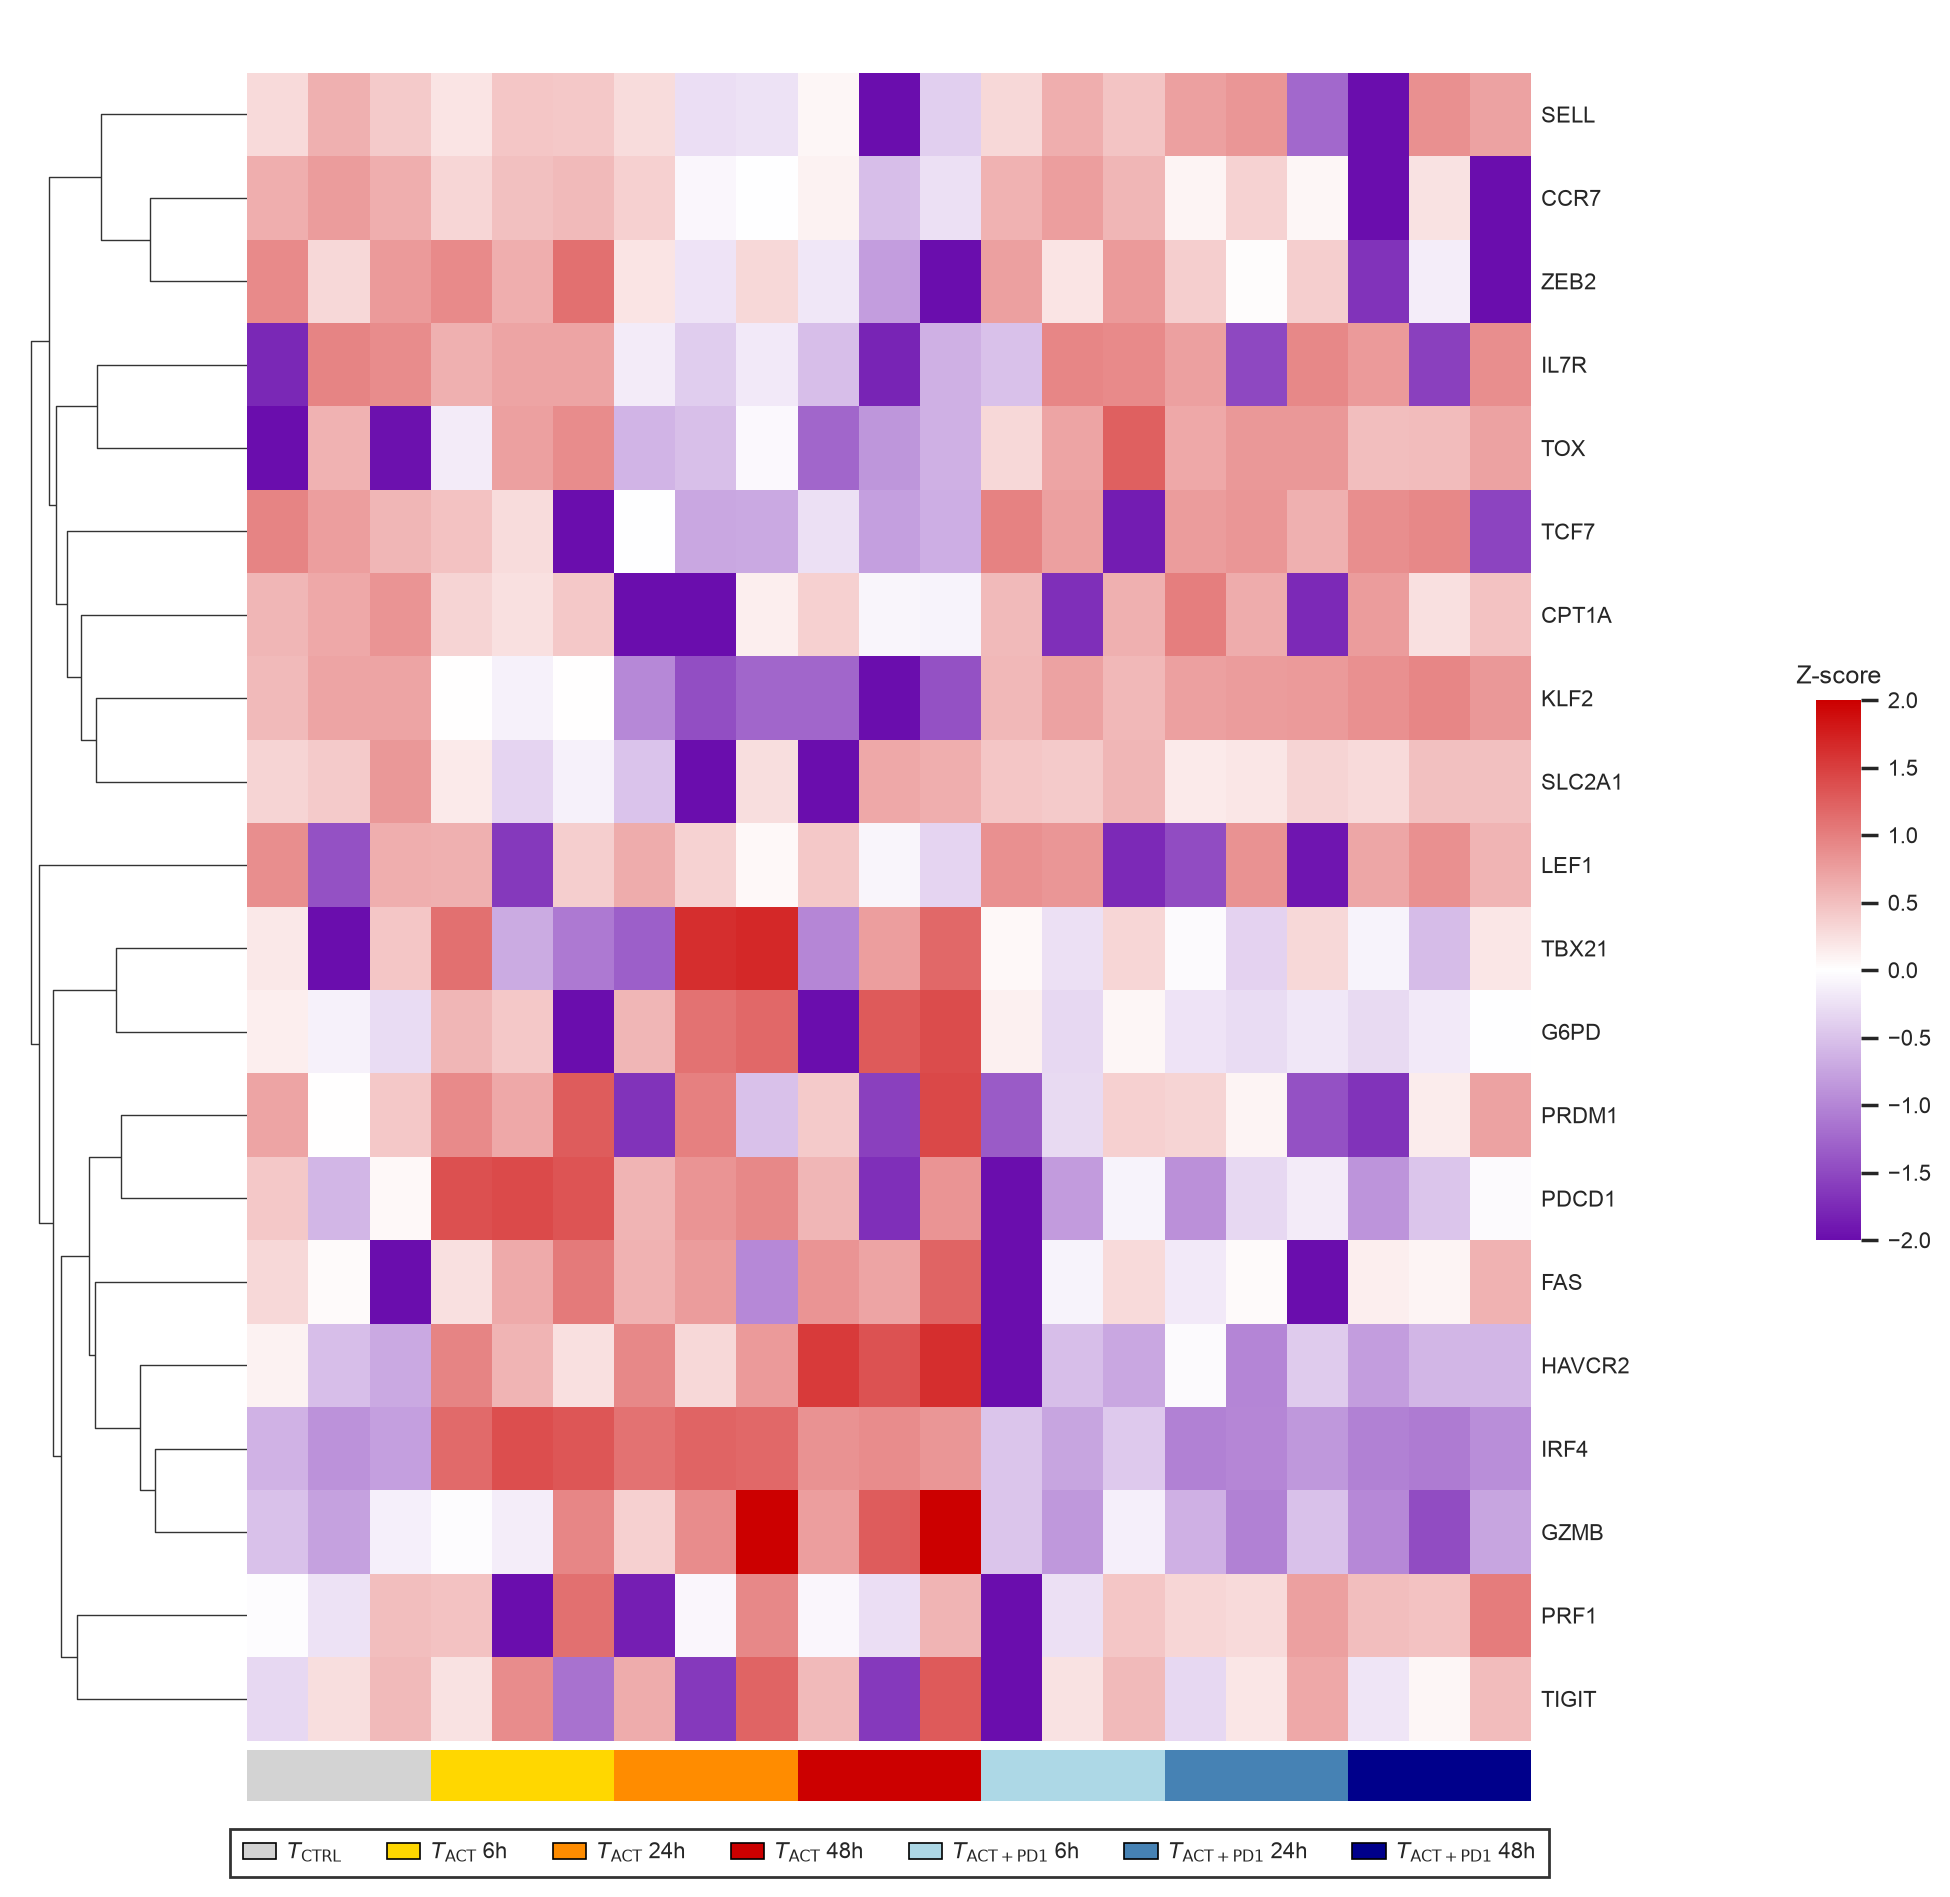

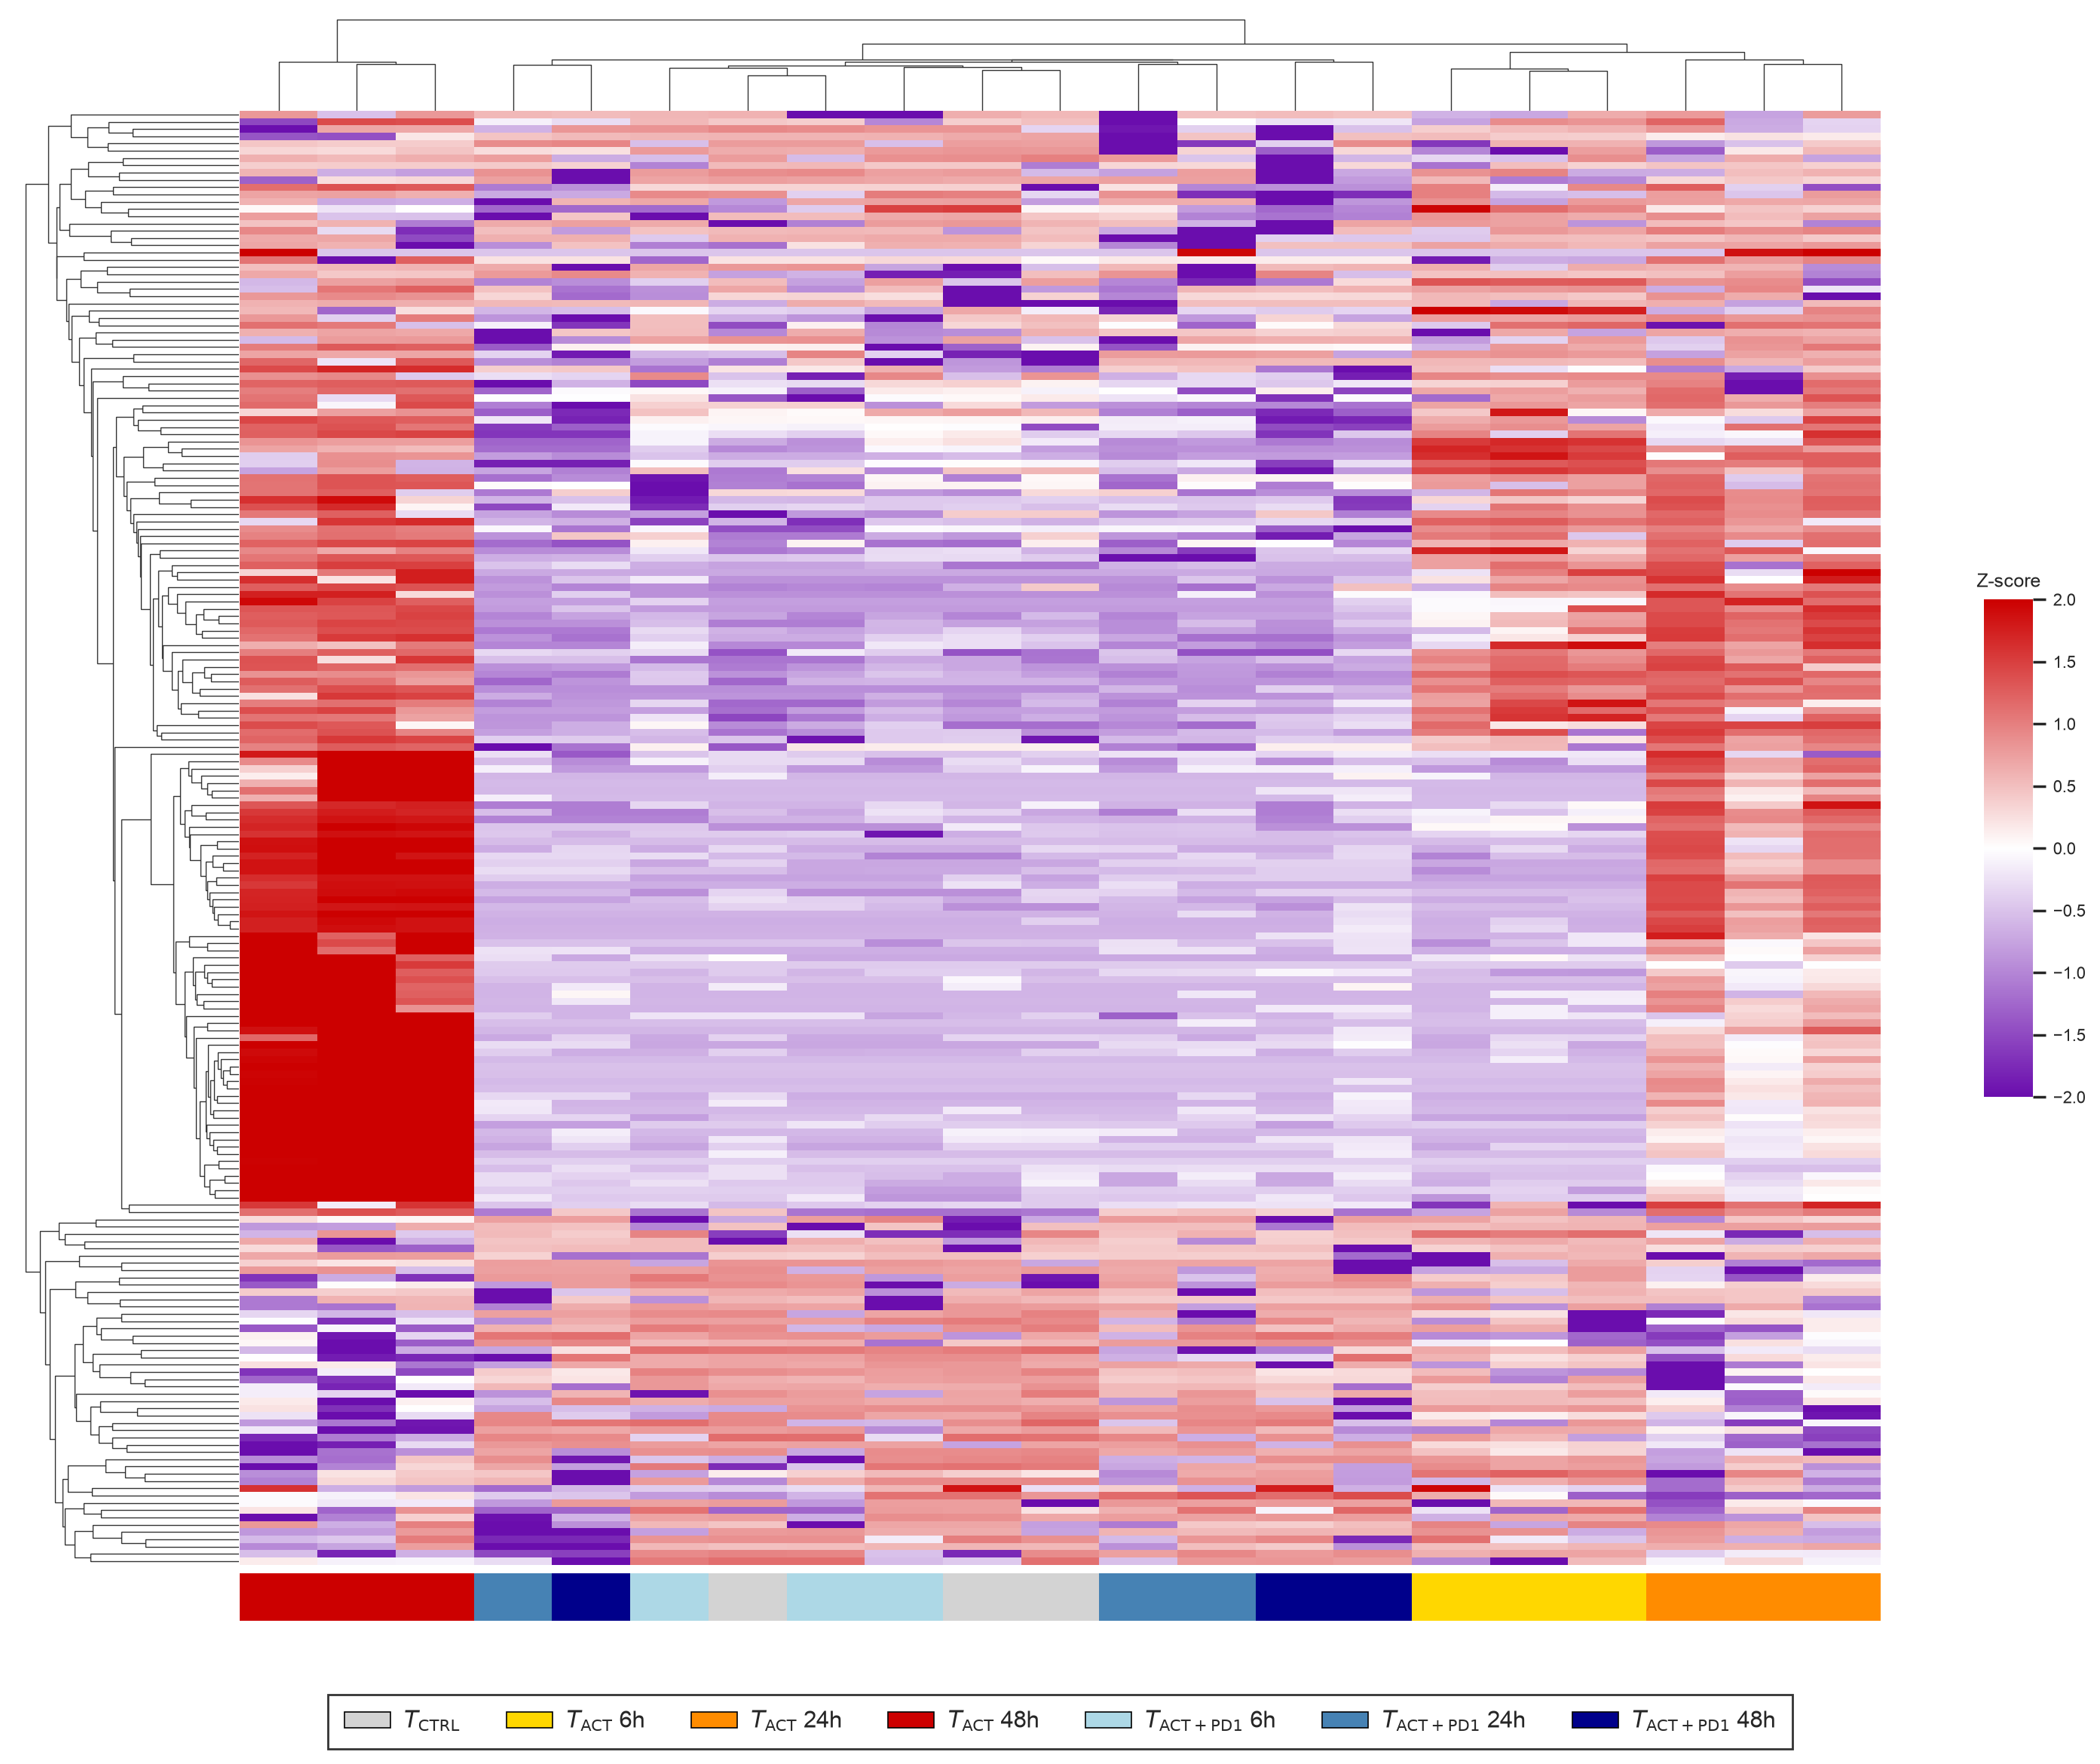

In [9]:
curated_genes = ["TCF7", "KLF2", "IL7R", "CCR7", "SELL", "LEF1", "FAS", "IRF4", "PRDM1", "TBX21", "ZEB2", "GZMB", "PRF1", "PDCD1", "HAVCR2", "TIGIT", "TOX", "CPT1A", "SLC2A1", "G6PD"]
plot_gene_clustermap(expr, meta, genes=curated_genes, out_path="../outputs/figures/curated_gene_clustermap.png")
plot_clustermap(expr, meta, out_path="../outputs/figures/clustermap_top200_var_genes.png")